- In this notebook, we will see for a query document retrival is needed or not and retrieved documents are relevant or not if retrieval is needed.
- If LLM can answer from its parametric knowledge that is retrival not needed then query will directly go to LLM and process will be ended. 
- If retrieval is needed, then it will retrieve documents, relevance of retrieved documents will be evaluated.
- Documents which are not relevant will be ignored for further steps as part of self-reflection. Answer will be generated on retrieved relevant documents only (will see in next notebooks).
- Answer will NOT be generated in this notebook for queries where retrieval is required.
- In later steps, we will implement further self-reflection steps pre and post answer generation for retrieval case.

## Loading API Key

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

## Loading Necessary Libraries

In [2]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END

C:\Users\koyel\AppData\Local\Temp\ipykernel_24744\2711615123.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader
c:\Users\koyel\Downloads\python_practice\ai_ml_learning_journey\genai_and_agenticai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Initial Basic Steps
- Document Loading
- Chunking 
- Embedding
- Storing to VectorDB 

In [3]:
docs = DirectoryLoader(
    path = 'documents', 
    glob = '*.pdf',
    loader_cls = PyPDFLoader
).load()

- For chunking, values for parameters `chunk_size` and `chunk_overlap` is experimentally got here.

In [4]:
chunks = RecursiveCharacterTextSplitter(chunk_size = 600, chunk_overlap = 150).split_documents(docs)
embeddings = OpenAIEmbeddings(model = "text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)

## Creation of Retriever Object for Further Use

In [5]:
retriever = vector_store.as_retriever(search_kwargs = {'k': 4})

## LLM Object Creation

In [6]:
llm = ChatOpenAI(model = "gpt-4o-mini", temperature = 0)

## Define State
- `state` is a class which carries variables and their values at different steps of the workflow.
- Variables in `state` are modified as workflow proceeds.
- Variables:
    - `question`: user query
    - `need_retrieval`: basis on we rout
    - `docs`: list of all retrieved docs
    - `relevant_docs`: list of relevant documents
    - `answer`: final answer which will be showed to user
- Can add description in schema itself.
- Here `relevant_docs` is newly added in `state` of the workflow.

In [7]:
class State(TypedDict):
    question: str
    need_retrieval: bool
    
    docs: List[Document] 
    relevant_docs: List[Document] 
    answer: str

## Define Output Schema and Prompt of Node to Decide Retrival
- This below part is to create node for should_retrieve
- Class `RetrieveDecicision` has only one variable `should_retrieve` which is a boolean variable as this output schema will be used for getting structured output from node `decide_retrieval`.

In [8]:
class RetrieveDecicision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description = "True if external documents are needed to answer reliably, else False"
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve = True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve = False for general explanations, definitions, or reasoning taht doesn't need sources.\n"
            "- If unsure. choose True."
        ),
        ("human", "Question: {question}")
    ]
)

- **`IMPORTANT`**: NO `.content` for structured output.

In [16]:
should_retrieve_llm = llm.with_structured_output(RetrieveDecicision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecicision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question = state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

## Define Prompt of Node to Generate Answer Via LLM
- As of this notebook below part will create answer for queries which are going to answer generating LLM directly without document retrieval.
- In later steps, post document retrieval and evaluation query will come to this node along with useful documents (if any) for answer generaion.

In [17]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specifics sources, say:\n"
            "I don't know based on my general knowledge."
        ),
        ("human", "{question}")
    ]
)

def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question = state["question"]
        )
    )
    return {
        "answer": out.content
    }

## Node for Retrieval
- This node will be used in case `decide_retrieval` decides that query requires to retrieve document. 

In [23]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

## Node for Evaluating Relevance of Retrieved Documents
- The `is_relevant` node present in below section will decide relevance of retrieved documents.
- It is working with LLM with output schema `RelevanceDecision` which is having a boolean variable which tells relevant or not.
- Here is required prompt for judging relevance as well.

In [24]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description = "true if the documment helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You ar a judging document relavance.\n"
            "Return the JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        )
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision)


def is_relevant(state: State):

    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question = state["question"],
                document = doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}

## Routing Node Function 
- `route_after_decide` will decide to retrieve documents or directly send query to answer generating LLM.

In [25]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

## Define Graph
-  `retrieve` node is temporary end for retrieval path, as reasons discussed earlier.
- Here in defining graph, node `is_relevant` along with edge `retrieve` to `is_relevant` and `is_relevant` to END is newly added.

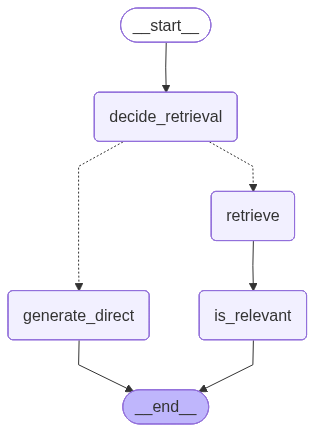

In [26]:
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("is_relevant", is_relevant) # new

g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve"
    }
)


g.add_edge("generate_direct", END) 
g.add_edge("retrieve", "is_relevant") # new added
g.add_edge("is_relevant", END) # temporary end for retrieval path

app = g.compile()
app

## Test on Questions
- Now we will see the decision on retrieval needed or not with two questions.

#### Question - 1:

In [27]:
result1 = app.invoke(
    {
        "question": "Who is the CEO of Noventra Systems?",
        "is_retrieval_required": False,
        "docs": [],
        "answer": ""
    }
)

In [28]:
print(result1["need_retrieval"])

True


In [29]:
result1['docs']

[Document(id='7acfc10d-435a-44d1-9c2d-d6cd2d55f0da', metadata={'producer': 'Microsoft® Word 2021', 'creator': 'Microsoft® Word 2021', 'creationdate': '2026-07-17T17:01:16+05:30', 'author': 'Koyel Pramanick', 'moddate': '2026-07-17T17:01:16+05:30', 'source': 'documents\\Company_Profile.pdf', 'total_pages': 4, 'page': 1, 'page_label': '2'}, page_content='assistants, workflow automation, analytics platforms, and enterprise collaboration software. \nToday, Noventra serves customers in more than 25 countries through regional offices and partner \nnetworks. \n \nFounders \nDr. Arjun Mehta \nFounder & Chief Executive Officer (CEO) \nDr. Mehta previously led enterprise AI research initiatives and has over 18 years of experience in \nartificial intelligence and cloud technologies. \n \nPriya Raman \nCo-Founder & Chief Product Officer (CPO) \nPriya oversees product strategy, customer experience, and long-term product roadmap. \n \nEthan Brooks'),
 Document(id='1ad16d03-7fa9-4701-9226-9502c03130c

In [30]:
for doc in result1["docs"]:
    print(doc.page_content)
    print("*"*100)

assistants, workflow automation, analytics platforms, and enterprise collaboration software. 
Today, Noventra serves customers in more than 25 countries through regional offices and partner 
networks. 
 
Founders 
Dr. Arjun Mehta 
Founder & Chief Executive Officer (CEO) 
Dr. Mehta previously led enterprise AI research initiatives and has over 18 years of experience in 
artificial intelligence and cloud technologies. 
 
Priya Raman 
Co-Founder & Chief Product Officer (CPO) 
Priya oversees product strategy, customer experience, and long-term product roadmap. 
 
Ethan Brooks
****************************************************************************************************
Noventra Systems 
Company Overview 
Noventra Systems is a fictional technology company specializing in enterprise productivity software, 
AI-powered automation platforms, knowledge management solutions, and digital workplace 
transformation. 
Founded with the objective of simplifying how organizations access informatio

In [31]:
for doc in result1["relevant_docs"]: # during generation only relevant docs will be used, not all retrieved docs
    print(doc.page_content)
    print("*"*100)

assistants, workflow automation, analytics platforms, and enterprise collaboration software. 
Today, Noventra serves customers in more than 25 countries through regional offices and partner 
networks. 
 
Founders 
Dr. Arjun Mehta 
Founder & Chief Executive Officer (CEO) 
Dr. Mehta previously led enterprise AI research initiatives and has over 18 years of experience in 
artificial intelligence and cloud technologies. 
 
Priya Raman 
Co-Founder & Chief Product Officer (CPO) 
Priya oversees product strategy, customer experience, and long-term product roadmap. 
 
Ethan Brooks
****************************************************************************************************


In [32]:
print(result1["answer"])

- For above query retrieval should be needed.
- So, state variable `need_retrieval` is `True`.
- Retrieved documents can be seen.
- Also relevant documents can be seen. All retrieved documents are not relevant, only one is required.
- As discussed earlier, post documents retrieval, answer generation part is not implemented yet, so state variable `answer` has nothing to print.

#### Question - 2:

In [33]:
result2 = app.invoke(
    {
        "question": "What is machine learning?",
        "is_retrieval_required": False,
        "docs": [],
        "answer": ""
    }
)

In [34]:
print(result2["need_retrieval"])

False


In [35]:
print(result1["answer"])

In [36]:
result2['docs']

[]

- For above query retrieval should NOT be needed.
- So, `need_retrieval` is `False`.
- As no documents were retrieved, state variable `docs` is empty list.
- Here LLM can generate answer for queries where document retrieval is not needed. So, state variable `answer` is showing the answer.